# 02 - Bicubic Baseline

## Why a baseline at all?

Before training any neural network we need a number to beat. Bicubic
interpolation is the standard choice for super-resolution because:

1. It is what you get for free from any image library, so it costs nothing.
2. It has **no parameters and no training**, so it cannot overfit and it cannot
   be accused of memorising the data.
3. It is genuinely decent. A neural network that does not beat bicubic is not
   worth deploying, and saying so honestly is more useful than a nice-looking
   plot.

**Fairness rule.** The baseline must go through *exactly* the same preprocessing
as the neural model: same band reordering, same reflectance conversion, same
per-image target size. Otherwise the comparison measures preprocessing, not the
model.

```
LR tif -> reorder bands [2,1,0,3] -> reflectance -> bicubic resize to the
          EXACT size of the matching HR file -> compare against HR/10000
```

In [1]:
import sys, os, json

if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
sys.path.insert(0, os.getcwd())

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data import list_pairs, load_pair
from src.metrics import (compute_all, compute_per_band, summarise,
                         dark_band_images)
from src.inference import bicubic_upsample, fit_calibration, calibrated_bicubic
from src.train_utils import load_config
from src.visualize import comparison_panel, to_rgb

cfg = load_config("configs/baseline.yaml")
ROOT, HR_SCALE = ".", cfg["data"]["hr_scale"]
OUT = "experiments/bicubic"
os.makedirs(OUT, exist_ok=True)
print("output folder:", OUT)

output folder: experiments/bicubic


## The baseline in full

The whole method is five lines. That is the point of a baseline.

In [2]:
def bicubic_predict(lr_path, hr_path):
    """One LR/HR pair -> (bicubic prediction, ground truth, LR input)."""
    lr, hr = load_pair(lr_path, hr_path, HR_SCALE)   # bands reordered, reflectance
    pred = bicubic_upsample(lr, hr.shape[:2])        # EXACT target size, per image
    return pred, hr, lr

lr, hr = load_pair("train/LR/1.tif", "train/HR/1.tif", HR_SCALE)
print("LR in :", lr.shape, lr.dtype, "mean %.4f" % lr.mean())
print("HR gt :", hr.shape, hr.dtype, "mean %.4f" % hr.mean())
print("pred  :", bicubic_upsample(lr, hr.shape[:2]).shape, " <- matches HR exactly")

LR in : (48, 48, 4) float32 mean 0.0910
HR gt : (318, 322, 4) float32 mean 0.0585
pred  : (318, 322, 4)  <- matches HR exactly


## Run the baseline over every split

We score train, val and test. Test is scored here only to have a final reference
number; **no model selection ever uses it.**

In [3]:
def run_split(split):
    per_image, per_band = [], []
    for name, lp, hp in list_pairs(ROOT, split):
        pred, hr, lr = bicubic_predict(lp, hp)
        m = compute_all(pred, hr, lr_shape=lr.shape[:2])
        m.update({"name": name, "split": split,
                  "height": hr.shape[0], "width": hr.shape[1]})
        per_image.append(m)
        for b in compute_per_band(pred, hr):
            b.update({"name": name, "split": split})
            per_band.append(b)
    return pd.DataFrame(per_image), pd.DataFrame(per_band)

img_frames, band_frames = [], []
for split in ["train", "val", "test"]:
    a, b = run_split(split)
    img_frames.append(a); band_frames.append(b)
    print("{:5s}  {:3d} images  PSNR {:.2f} dB  SSIM {:.3f}".format(
        split, len(a), a.psnr.mean(), a.ssim.mean()))

per_image = pd.concat(img_frames, ignore_index=True)
per_band = pd.concat(band_frames, ignore_index=True)

train  100 images  PSNR 23.35 dB  SSIM 0.650


val     20 images  PSNR 22.49 dB  SSIM 0.614


test    20 images  PSNR 23.25 dB  SSIM 0.657


## Results: mean, median and standard deviation

In [4]:
METRICS = ["psnr", "ssim", "mae", "rmse", "sam", "ergas"]

stats = per_image.groupby("split")[METRICS].agg(["mean", "median", "std"]).round(4)
display(stats)

print("\nMetric directions:  PSNR up is better,  SSIM up is better,")
print("                    MAE / RMSE / SAM / ERGAS down is better.")

psnr                     ssim                     mae          \
          mean   median     std    mean  median     std    mean  median   
split                                                                     
test   23.2522  23.2472  3.1838  0.6569  0.6690  0.1787  0.0505  0.0487   
train  23.3456  23.0118  4.4232  0.6497  0.6713  0.1710  0.0587  0.0521   
val    22.4922  24.5246  4.8712  0.6143  0.6715  0.1808  0.0688  0.0479   

                 rmse                     sam                    ergas  \
          std    mean  median     std    mean  median     std     mean   
split                                                                    
test   0.0193  0.0730  0.0688  0.0251  5.5178  5.8957  2.5972  10.6868   
train  0.0536  0.0784  0.0707  0.0572  6.9820  5.8425  4.7448  11.4506   
val    0.0607  0.0910  0.0594  0.0755  9.2655  6.7677  8.7667  36.9877   

                        
       median      std  
split                   
test   8.9296   6.1640  
train  9.5148   9.5499  
val    9.5852  75.0712


Metric directions:  PSNR up is better,  SSIM up is better,
                    MAE / RMSE / SAM / ERGAS down is better.


## Per-band results

This is where the dataset gets interesting. Look at the NIR row.

psnr    ssim     mae    rmse
split band                                  
test  Blue   31.4888  0.7630  0.0253  0.0351
      Green  27.7551  0.7012  0.0369  0.0476
      NIR    19.9584  0.4870  0.0957  0.1120
      Red    27.1963  0.6764  0.0442  0.0567
train Blue   29.1146  0.7264  0.0380  0.0481
      Green  26.9067  0.6955  0.0465  0.0574
      NIR    20.0967  0.5152  0.0967  0.1126
      Red    25.5549  0.6617  0.0535  0.0664
val   Blue   27.5515  0.6793  0.0503  0.0636
      Green  25.7227  0.6579  0.0568  0.0702
      NIR    19.7186  0.4984  0.1049  0.1208
      Red    24.9005  0.6215  0.0632  0.0774

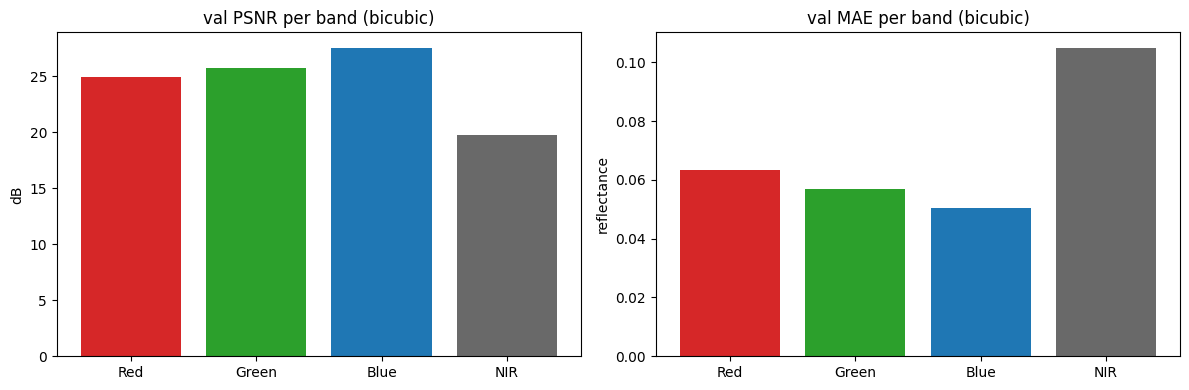

In [5]:
pb = per_band.groupby(["split", "band"])[["psnr", "ssim", "mae", "rmse"]].mean().round(4)
display(pb)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
order = ["Red", "Green", "Blue", "NIR"]
v = per_band[per_band.split == "val"]
ax[0].bar(order, [v[v.band == b].psnr.mean() for b in order],
          color=["tab:red", "tab:green", "tab:blue", "dimgray"])
ax[0].set_title("val PSNR per band (bicubic)"); ax[0].set_ylabel("dB")
ax[1].bar(order, [v[v.band == b].mae.mean() for b in order],
          color=["tab:red", "tab:green", "tab:blue", "dimgray"])
ax[1].set_title("val MAE per band (bicubic)"); ax[1].set_ylabel("reflectance")
plt.tight_layout(); plt.show()

**NIR scores far worse than the visible bands.** That is not a bug in the
baseline. Two things cause it:

1. NIR reflectance is roughly twice as large as the visible bands, so the same
   relative error becomes a much larger absolute error.
2. LR and HR come from different sensors, and their NIR filters do not have
   identical response curves. Bicubic copies the LR value straight through and
   cannot correct that offset.

Point 2 is exactly the kind of thing a learned model *can* fix, so this is the
clearest place to look for an improvement from FlexScaleSR.

## Distribution of scores, and where bicubic struggles

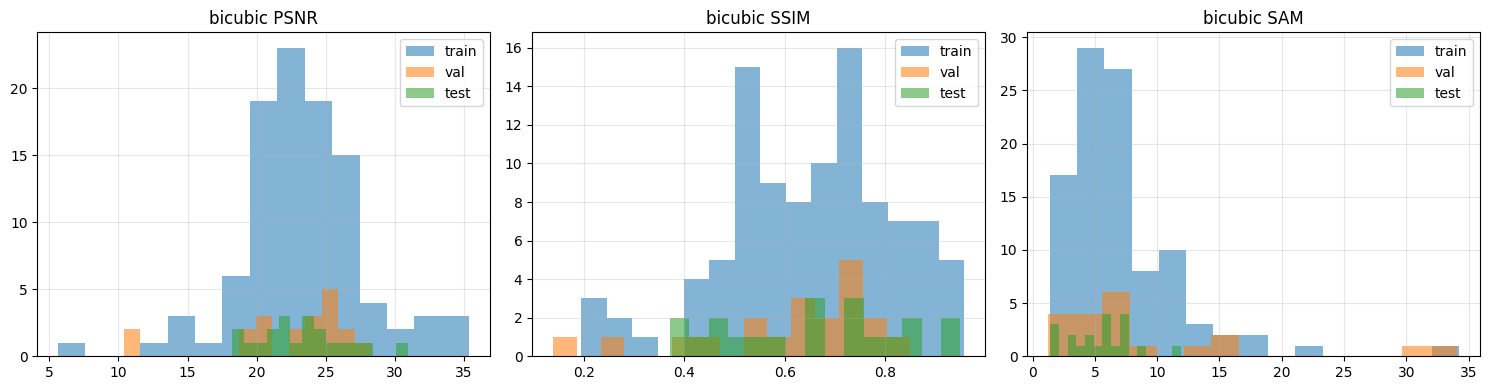

hardest val images for bicubic:


,name,psnr,ssim,sam,ergas
118,19.tif,10.365,0.251,30.368,270.769
116,17.tif,10.380,0.138,34.079,235.246
107,8.tif,18.819,0.422,5.106,54.570


easiest val images for bicubic:


,name,psnr,ssim,sam,ergas
119,20.tif,26.542,0.658,5.300,6.573
111,12.tif,26.693,0.761,15.907,7.689
108,9.tif,28.285,0.659,3.186,4.930


In [6]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
for a, m in zip(ax, ["psnr", "ssim", "sam"]):
    for split in ["train", "val", "test"]:
        a.hist(per_image[per_image.split == split][m], bins=15, alpha=0.55, label=split)
    a.set_title("bicubic " + m.upper()); a.legend(); a.grid(alpha=0.3)
plt.tight_layout(); plt.show()

val = per_image[per_image.split == "val"].sort_values("psnr")
print("hardest val images for bicubic:")
display(val.head(3)[["name", "psnr", "ssim", "sam", "ergas"]].round(3))
print("easiest val images for bicubic:")
display(val.tail(3)[["name", "psnr", "ssim", "sam", "ergas"]].round(3))

## Representative visualisations

We deliberately show an easy case, a typical case and a hard case. Showing only
the best result would be dishonest.

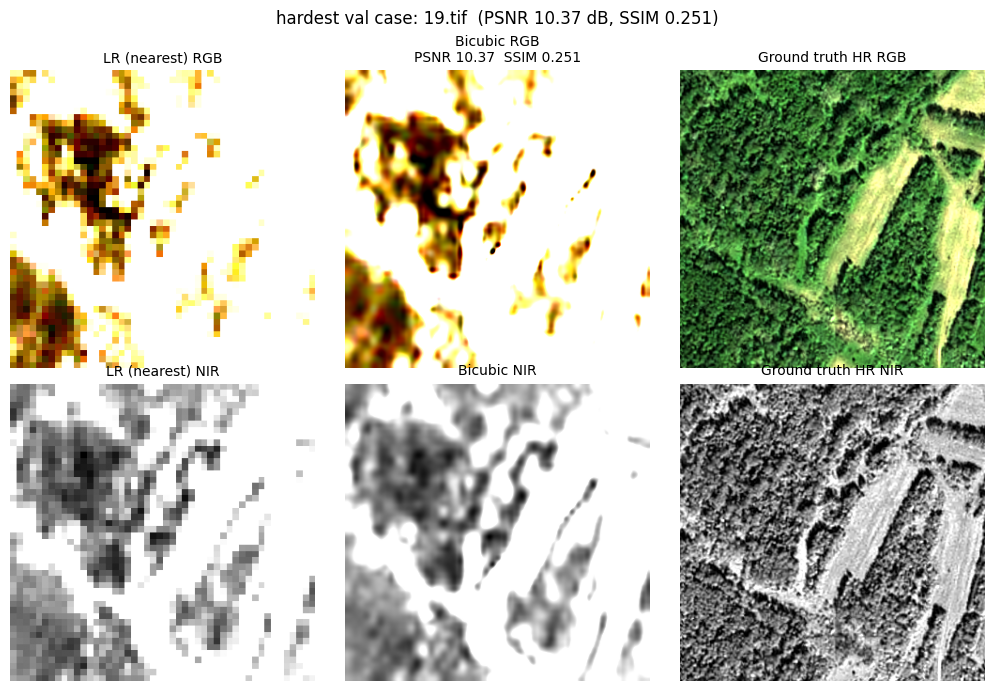

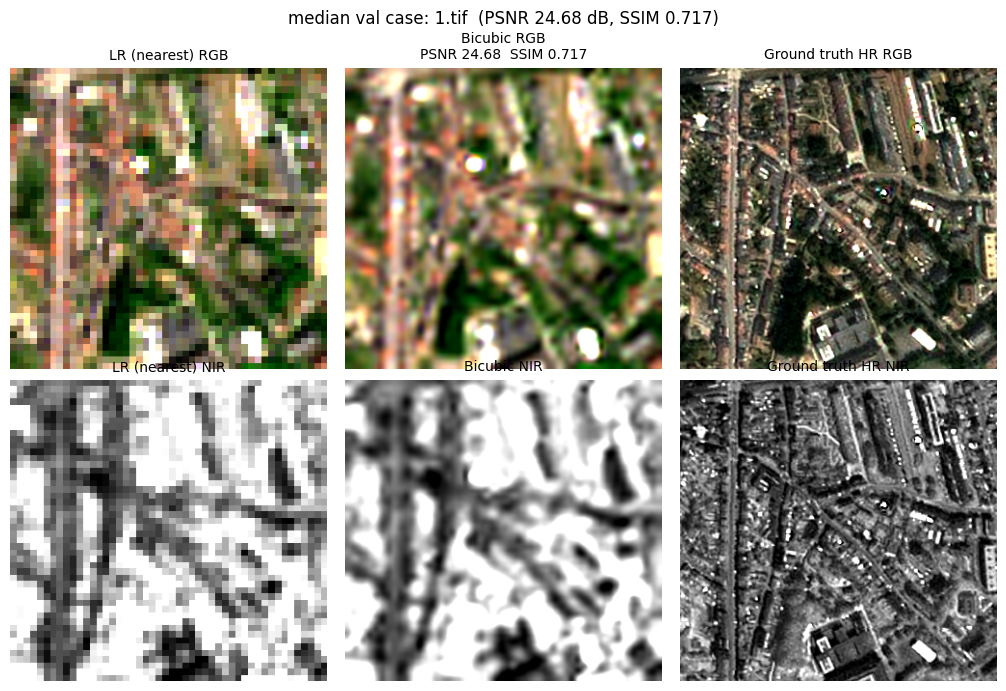

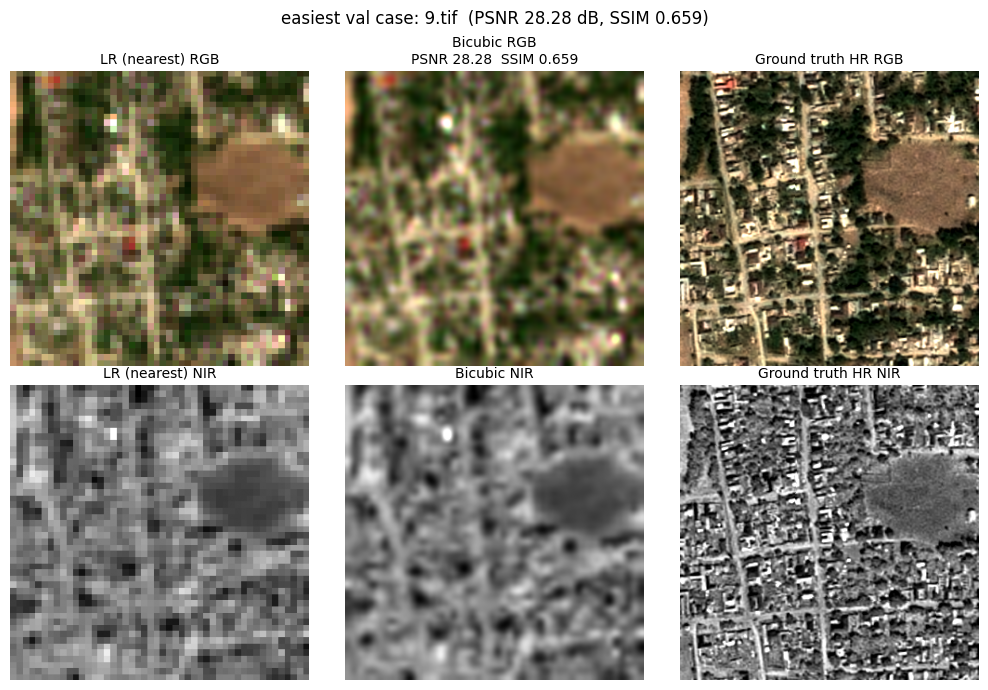

In [7]:
val_sorted = per_image[per_image.split == "val"].sort_values("psnr").reset_index(drop=True)
picks = [("hardest", val_sorted.iloc[0]),
         ("median", val_sorted.iloc[len(val_sorted) // 2]),
         ("easiest", val_sorted.iloc[-1])]

for label, row in picks:
    lp = os.path.join(ROOT, "val", "LR", row["name"])
    hp = os.path.join(ROOT, "val", "HR", row["name"])
    pred, hr, lr = bicubic_predict(lp, hp)
    fig = comparison_panel(
        lr, pred, None, hr,
        name="{} val case: {}  (PSNR {:.2f} dB, SSIM {:.3f})".format(
            label, row["name"], row["psnr"], row["ssim"]),
        metrics={"Bicubic": {"psnr": row["psnr"], "ssim": row["ssim"]}},
        save_path=os.path.join(OUT, "bicubic_" + label + "_" + row["name"] + ".png"))
    plt.show()

---

# Baseline 2: bicubic + global sensor calibration

Look again at the per-band numbers. Bicubic is not just blurry, it is the wrong
BRIGHTNESS, and by a different amount in each band. That is because LR and HR
come from two different satellites whose calibrations do not agree.

We can measure that mismatch with four numbers, one gain per band:

```
HR_band  =  gain_band  x  bicubic(LR)_band
```

The gains are fitted on the **training split only** and then applied unchanged
to validation and test, so nothing leaks.

This matters for honesty. If a neural network beats plain bicubic, some of that
win is just brightness correction that four multiplications also achieve. This
baseline separates the two, and it is the number FlexScaleSR really has to beat.

In [8]:
gains = fit_calibration(".", split="train", hr_scale=HR_SCALE)

print("per-band gains, fitted on train only:")
for b, g in zip(["Red", "Green", "Blue", "NIR"], gains):
    print("  %-6s gain %.4f   LR reads %.1f%% brighter than HR" % (b, g, 100 * (1 / g - 1)))
print()
print("NIR is the most mismatched band, which is exactly where bicubic scored worst.")

per-band gains, fitted on train only:
  Red    gain 0.7744   LR reads 29.1% brighter than HR
  Green  gain 0.8020   LR reads 24.7% brighter than HR
  Blue   gain 0.8496   LR reads 17.7% brighter than HR
  NIR    gain 0.7107   LR reads 40.7% brighter than HR

NIR is the most mismatched band, which is exactly where bicubic scored worst.


In [9]:
def run_split_calibrated(split):
    rows, brows = [], []
    for name, lp, hp in list_pairs(ROOT, split):
        lr, hr = load_pair(lp, hp, HR_SCALE)
        pred = calibrated_bicubic(lr, hr.shape[:2], gains)
        m = compute_all(pred, hr, lr_shape=lr.shape[:2])
        m.update({"name": name, "split": split, "method": "Bicubic+calib"})
        rows.append(m)
        for b in compute_per_band(pred, hr):
            b.update({"name": name, "split": split, "method": "Bicubic+calib"})
            brows.append(b)
    return pd.DataFrame(rows), pd.DataFrame(brows)

cal_imgs, cal_bands = [], []
for split in ["train", "val", "test"]:
    a, b = run_split_calibrated(split)
    cal_imgs.append(a); cal_bands.append(b)
cal_per_image = pd.concat(cal_imgs, ignore_index=True)
cal_per_band = pd.concat(cal_bands, ignore_index=True)

per_image["method"] = "Bicubic"
per_band["method"] = "Bicubic"
both = pd.concat([per_image, cal_per_image], ignore_index=True)
both_bands = pd.concat([per_band, cal_per_band], ignore_index=True)

print("MEAN over images")
display(both.groupby(["split", "method"])[METRICS].mean().round(4))
print("MEDIAN over images  (ERGAS mean is distorted by a few dark scenes)")
display(both.groupby(["split", "method"])[METRICS].median().round(4))

MEAN over images


psnr    ssim     mae    rmse      sam    ergas
split method                                                          
test  Bicubic        23.2522  0.6569  0.0505  0.0730   5.5178  10.6868
      Bicubic+calib  25.6184  0.6828  0.0377  0.0555   6.2651   8.2605
train Bicubic        23.3456  0.6497  0.0587  0.0784   6.9820  11.4506
      Bicubic+calib  26.0772  0.6792  0.0448  0.0609   7.5998   8.9475
val   Bicubic        22.4922  0.6143  0.0688  0.0910   9.2655  36.9877
      Bicubic+calib  24.9187  0.6480  0.0499  0.0676  10.6565  29.2532

MEDIAN over images  (ERGAS mean is distorted by a few dark scenes)


psnr    ssim     mae    rmse     sam   ergas
split method                                                        
test  Bicubic        23.2472  0.6690  0.0487  0.0688  5.8957  8.9296
      Bicubic+calib  25.7785  0.7268  0.0370  0.0515  6.2450  7.3270
train Bicubic        23.0118  0.6713  0.0521  0.0707  5.8425  9.5148
      Bicubic+calib  25.8491  0.6990  0.0344  0.0510  6.5752  7.4095
val   Bicubic        24.5246  0.6715  0.0479  0.0594  6.7677  9.5852
      Bicubic+calib  26.1799  0.6894  0.0370  0.0491  7.7806  7.3607

### How much of the bicubic error was just calibration?

In [10]:
for split in ["val", "test"]:
    a = both[(both.split == split) & (both.method == "Bicubic")]
    b = both[(both.split == split) & (both.method == "Bicubic+calib")]
    mse_a = (a.rmse.values ** 2).mean()
    mse_b = (b.rmse.values ** 2).mean()
    print("%-5s  PSNR %.3f -> %.3f dB   MSE %.6f -> %.6f   %.1f%% of the error "
          "was global calibration"
          % (split, a.psnr.mean(), b.psnr.mean(), mse_a, mse_b,
             100 * (mse_a - mse_b) / mse_a))

pbt = both_bands.pivot_table(index=["split", "band"], columns="method", values="psnr")
pbt["gain_dB"] = (pbt["Bicubic+calib"] - pbt["Bicubic"]).round(3)
print()
display(pbt.round(3))

val    PSNR 22.492 -> 24.919 dB   MSE 0.013690 -> 0.007626   44.3% of the error was global calibration
test   PSNR 23.252 -> 25.618 dB   MSE 0.005935 -> 0.003394   42.8% of the error was global calibration



method       Bicubic  Bicubic+calib  gain_dB
split band                                  
test  Blue    31.489         32.020    0.531
      Green   27.755         29.569    1.814
      NIR     19.958         21.851    1.893
      Red     27.196         29.174    1.978
train Blue    29.115         30.166    1.051
      Green   26.907         28.789    1.882
      NIR     20.097         23.089    2.992
      Red     25.555         27.810    2.256
val   Blue    27.552         29.232    1.681
      Green   25.723         27.901    2.178
      NIR     19.719         21.948    2.229
      Red     24.900         27.174    2.273

**Reading of the result.** Roughly 43 percent of bicubic's squared error is a
global brightness mismatch that four numbers fix. Only the remaining half is
genuine spatial detail that super-resolution has to invent.

One honest wrinkle: SAM gets slightly **worse** after calibration. SAM measures
the angle between spectra and ignores overall brightness, so rescaling each band
by a different gain changes the spectral shape a little. Improving pixel accuracy
and improving spectral fidelity are not the same goal, and this is a clean
example of the tension.

In [11]:
CAL_OUT = "experiments/radiometric_baseline"
os.makedirs(CAL_OUT, exist_ok=True)
both.to_csv(os.path.join(CAL_OUT, "metrics_per_image.csv"), index=False)
both_bands.to_csv(os.path.join(CAL_OUT, "metrics_per_band.csv"), index=False)

with open(os.path.join(CAL_OUT, "calibration.json"), "w", encoding="utf-8") as f:
    json.dump({"band_order": ["Red", "Green", "Blue", "NIR"],
               "gains": [float(g) for g in gains],
               "fitted_on": "train split only",
               "form": "HR_band = gain_band * bicubic(LR)_band"}, f, indent=2)

cal_summary = {
    "method": "bicubic + global per-band sensor calibration",
    "gains": {b: float(g) for b, g in zip(["Red", "Green", "Blue", "NIR"], gains)},
    "per_split": {s: {m: summarise(g.to_dict("records"))
                      for m, g in gg.groupby("method")}
                  for s, gg in both.groupby("split")},
    "unreliable_ergas_scenes": sorted(set(dark_band_images(both.to_dict("records"), 0.02))),
}
with open(os.path.join(CAL_OUT, "summary.json"), "w", encoding="utf-8") as f:
    json.dump(cal_summary, f, indent=2)
print("saved to", CAL_OUT)
for f in sorted(os.listdir(CAL_OUT)):
    print("   ", f)

saved to experiments/radiometric_baseline
    calibration.json
    metrics_per_band.csv
    metrics_per_image.csv
    summary.json


## Save the results

Everything a report needs: per-image CSV, per-band CSV and a summary JSON.

In [12]:
per_image.to_csv(os.path.join(OUT, "metrics_per_image.csv"), index=False)
per_band.to_csv(os.path.join(OUT, "metrics_per_band.csv"), index=False)

summary = {
    "method": "bicubic interpolation",
    "preprocessing": {
        "lr_band_permutation": [2, 1, 0, 3],
        "canonical_band_order": ["R", "G", "B", "NIR"],
        "hr_scale": HR_SCALE,
        "target_size": "exact size of the matching HR file, per image",
    },
    "per_split": {s: summarise(g.to_dict("records"))
                  for s, g in per_image.groupby("split")},
    "per_band_val": pb.loc["val"].to_dict("index"),
}
with open(os.path.join(OUT, "summary.json"), "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2)

print("saved to", OUT)
for f in sorted(os.listdir(OUT)):
    print("   ", f)

saved to experiments/bicubic
    bicubic_easiest_9.tif.png
    bicubic_hardest_19.tif.png
    bicubic_median_1.tif.png
    metrics_per_band.csv
    metrics_per_image.csv
    summary.json


## Baseline scoreboard

These are the numbers FlexScaleSR must beat. **Validation is the row that
matters** - it is what we use to pick the best checkpoint.

In [13]:
board = both.groupby(["split", "method"])[METRICS].mean().round(4)
print("BASELINE SCOREBOARD  (mean over images)")
print(board.to_string())
print()
print("The bar FlexScaleSR has to clear is the Bicubic+calib row, not Bicubic.")

BASELINE SCOREBOARD  (mean over images)
                        psnr    ssim     mae    rmse      sam    ergas
split method                                                          
test  Bicubic        23.2522  0.6569  0.0505  0.0730   5.5178  10.6868
      Bicubic+calib  25.6184  0.6828  0.0377  0.0555   6.2651   8.2605
train Bicubic        23.3456  0.6497  0.0587  0.0784   6.9820  11.4506
      Bicubic+calib  26.0772  0.6792  0.0448  0.0609   7.5998   8.9475
val   Bicubic        22.4922  0.6143  0.0688  0.0910   9.2655  36.9877
      Bicubic+calib  24.9187  0.6480  0.0499  0.0676  10.6565  29.2532

The bar FlexScaleSR has to clear is the Bicubic+calib row, not Bicubic.


---

Next: `03_train_super_resolution.ipynb` trains FlexScaleSR.
Then `04_evaluate_and_visualize.ipynb` puts the two methods side by side.